In [2]:
!pip install pandas numpy matplotlib statsmodels requests

Overall pipeline:
1. Load & clean data
2. Pair selection diagnostics
      - correlation
      - cointegration test
3. Hedge ratio estimation
4. Spread construction
5. Spread diagnostics
      - ADF stationarity test
      - half-life estimation
6. Signal construction
7. Backtest
8. Sensitivity analysis
      - entry/exit thresholds
      - transaction costs
9. Performance evaluation
10. (Optional) multi-pair portfolio

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

In [18]:
df_A = pd.read_csv("data/SPY.csv")
df_B = pd.read_csv("data/QQQ.csv")

In [20]:
df_A.head()

,timestamp,open,high,low,close,volume
0,2022-09-30 04:00:00,366.02,366.13,366.02,366.08,8354
1,2022-09-30 04:01:00,366.11,366.13,366.07,366.13,1100
2,2022-09-30 04:02:00,365.98,365.98,365.87,365.91,600
3,2022-09-30 04:03:00,365.98,366.06,365.87,366.06,1800
4,2022-09-30 04:04:00,366.07,366.07,366.02,366.02,223


In [22]:
df_B.head()

,timestamp,open,high,low,close,volume
0,2022-09-30 04:00:00,274.00,274.84,274.00,274.65,5209
1,2022-09-30 04:01:00,274.70,274.73,274.63,274.68,12542
2,2022-09-30 04:02:00,274.61,274.61,274.48,274.50,7092
3,2022-09-30 04:03:00,274.47,274.52,274.42,274.47,9774
4,2022-09-30 04:04:00,274.55,274.61,274.55,274.55,500


In [24]:
# redefine column names
df_A.columns = ["datetime", "open", "high", "low", "close", "volume"]
df_B.columns = ["datetime", "open", "high", "low", "close", "volume"]

In [26]:
# Parse datetime
df_A["datetime"] = pd.to_datetime(df_A["datetime"])
df_B["datetime"] = pd.to_datetime(df_B["datetime"])

# Set index
df_A = df_A.set_index("datetime").sort_index()
df_B = df_B.set_index("datetime").sort_index()

# Merge close prices
df = pd.DataFrame({
    "A_close": df_A["close"],
    "B_close": df_B["close"]
}).dropna()

# Remove first and last 15 min
df = df.between_time("09:45", "15:45").copy()

# Log prices
df["logA"] = np.log(df["A_close"])
df["logB"] = np.log(df["B_close"])

df.head()

,A_close,B_close,logA,logB
datetime,,,,
2022-09-30 09:45:00,362.23,272.0000,5.892279,5.605802
2022-09-30 09:46:00,361.63,271.4500,5.890622,5.603778
2022-09-30 09:47:00,361.88,271.6200,5.891313,5.604404
2022-09-30 09:48:00,360.95,270.8659,5.888739,5.601624
2022-09-30 09:49:00,361.52,271.3518,5.890317,5.603416


In [28]:
df.shape
df.head()

,A_close,B_close,logA,logB
datetime,,,,
2022-09-30 09:45:00,362.23,272.0000,5.892279,5.605802
2022-09-30 09:46:00,361.63,271.4500,5.890622,5.603778
2022-09-30 09:47:00,361.88,271.6200,5.891313,5.604404
2022-09-30 09:48:00,360.95,270.8659,5.888739,5.601624
2022-09-30 09:49:00,361.52,271.3518,5.890317,5.603416


In [30]:
# full sample cointegration test
score, pvalue, _ = coint(df["logA"], df["logB"])
print("Full-sample cointegration p-value:", pvalue)

if pvalue < 0.05:
    print("Full sample suggests cointegration.")
else:
    print("Full sample does NOT strongly support cointegration.")

Full-sample cointegration p-value: 0.09496401548203265
Full sample does NOT strongly support cointegration.


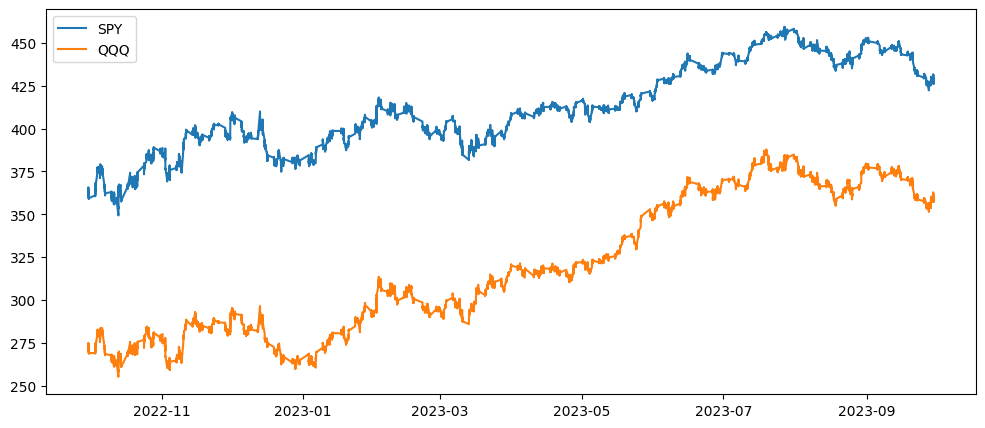

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df["A_close"], label="SPY")
plt.plot(df["B_close"], label="QQQ")
plt.legend()
plt.show()

## Estimate Hedge Ratio (OLS Regression)

In [31]:
import statsmodels.api as sm

# use log prices to stabilize variance and improve robustness.
logA = np.log(df["A_close"])
logB = np.log(df["B_close"])


X = sm.add_constant(logB)
model = sm.OLS(logA, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                A_close   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                 1.124e+06
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:29:44   Log-Likelihood:             2.4120e+05
No. Observations:               90406   AIC:                        -4.824e+05
Df Residuals:                   90404   BIC:                        -4.824e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2298      0.003   1227.722      0.0

Above plot provides some useful infromation, such as Beta, R-squared, statistical significance. 

In [34]:
lookback = 3 * 390   # 3 trading days of 1-minute bars

alphas = np.full(len(df), np.nan)
betas = np.full(len(df), np.nan)

for i in range(lookback, len(df)):
    y = df["logA"].iloc[i - lookback:i]
    x = df["logB"].iloc[i - lookback:i]
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    alphas[i] = model.params.iloc[0]
    betas[i] = model.params.iloc[1]

df["alpha"] = alphas
df["beta"] = betas

In [36]:
# statioanrity test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["spread"].dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -3.1850611531925153
p-value: 0.0208658468013303


In [ ]:
df["spread"] = df["logA"] - df["alpha"] - df["beta"] * df["logB"]

In [37]:
# optional half-life diagnostic
spread = df["spread"].dropna().copy()

spread_lag = spread.shift(1)
spread_ret = spread - spread_lag

hl_df = pd.DataFrame({
    "spread_ret": spread_ret,
    "spread_lag": spread_lag
}).dropna()

X = sm.add_constant(hl_df["spread_lag"])
hl_model = sm.OLS(hl_df["spread_ret"], X).fit()

lambda_coef = hl_model.params["spread_lag"]

if lambda_coef < 0:
    halflife = -np.log(2) / lambda_coef
    print("Estimated half-life:", halflife)
else:
    halflife = np.nan
    print("Half-life not meaningful because mean reversion coefficient is non-negative.")

Estimated half-life: 4441.8778067377025


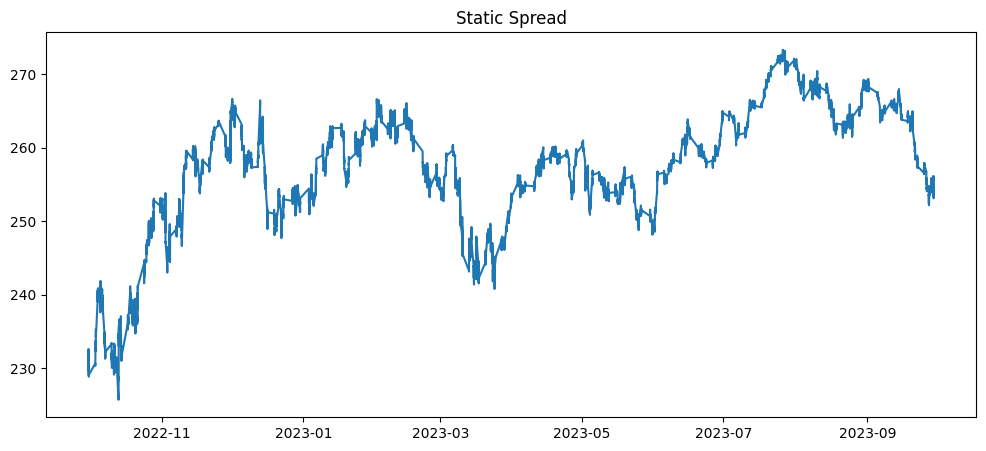

In [38]:
plt.figure(figsize=(12,5))
plt.plot(df["spread"])
plt.title("Static Spread")
plt.show()

The static plot shows that there is oscillatory behavior because we see multiple cycles. 
It's not strictly stationary. 
Mean seems to drift over months. 


In [40]:
z_window = 120

df["spread_mean"] = df["spread"].rolling(z_window).mean()
df["spread_std"] = df["spread"].rolling(z_window).std()
df["zscore"] = (df["spread"] - df["spread_mean"]) / df["spread_std"]

We can have rolling window of 2-5 trading days. 

    We don't want to have too short rolling window because hedge ratio becomes unstable and it contains too mcuh noisy beta estimates.
    we don't want it too long neither because relationship may drift slow adaptation.


In [42]:
# 1. Compute Rolling Hedge Ratio

cov = df["A_close"].rolling(window).cov(df["B_close"])
var = df["B_close"].rolling(window).var()

df["hedge_ratio"] = cov / var

In [43]:
# 2. construct dynamic spread
df["spread"] = df["A_close"] - df["hedge_ratio"] * df["B_close"]

In [44]:
# 3. compute rolling z-socre
df["spread_mean"] = df["spread"].rolling(window).mean()
df["spread_std"] = df["spread"].rolling(window).std()

df["zscore"] = (df["spread"] - df["spread_mean"]) / df["spread_std"]

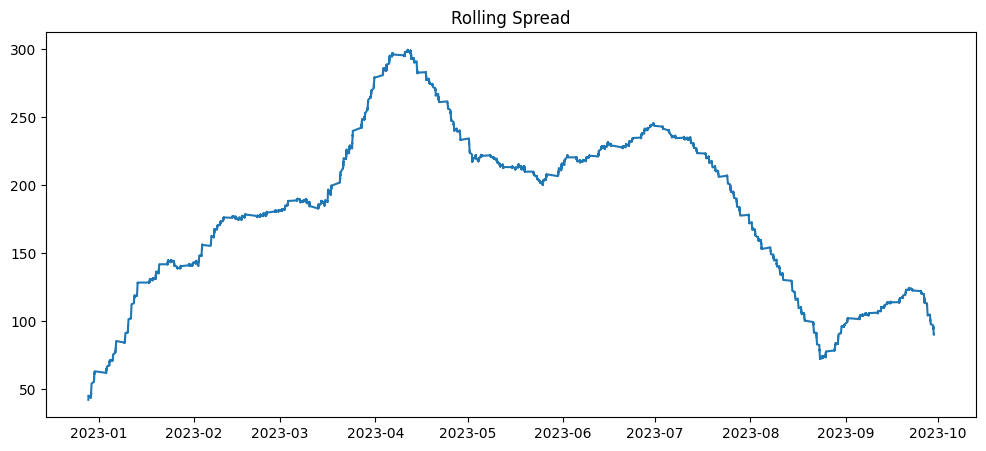

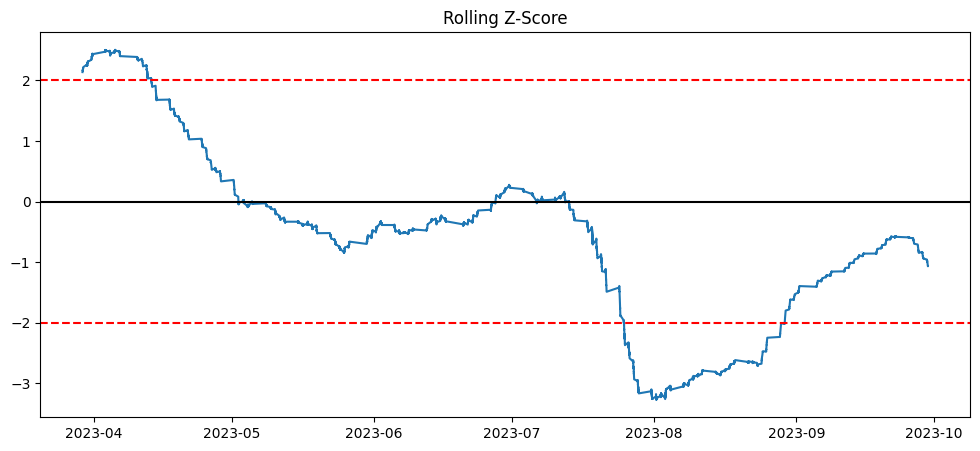

In [45]:
# 4. plot rolling spread and z_score
plt.figure(figsize=(12,5))
plt.plot(df["spread"])
plt.title("Rolling Spread")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["zscore"])
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.axhline(0, color='black')
plt.title("Rolling Z-Score")
plt.show()

Z-Score spikes those above 2 or below -2 are trading opprtunities

In [47]:
# 5. generate trading signals, trading raw signal
# thresholds
entry = 1.5
exit = 0.5

df["position_raw"] = 0

# entry signals
df.loc[df["zscore"] < -entry, "position_raw"] = 1   # long spread
df.loc[df["zscore"] > entry, "position_raw"] = -1   # short spread

# forward fill positions (hold trade)
df["position_raw"] = df["position_raw"].replace(0, np.nan).ffill()

# exit rule
df.loc[df["zscore"].abs() < exit, "position_raw"] = 0

# forward fill again to maintain flat state
df["position_raw"] = df["position_raw"].ffill().fillna(0)

In [62]:
# setting minimum holding period
#min_hold = 30  # 30 bars (hold 30 minutes if 1-min data)

df["position"] = df["position_raw"].copy()

#last_change_index = 0
#current_position = 0

#for i in range(1, len(df)):
#    if df["position"].iloc[i] != current_position: #detect position change 
#        # If trying to change position
#        if i - last_change_index < min_hold: # enforce minimum holding period
#            df["position"].iloc[i] = current_position # reject early exit
#        else: # allow change when holding period is satisfied
#            current_position = df["position"].iloc[i] 
#            last_change_index = i

In [64]:
# 6. compute strategy return
df["ret_A"] = df["A_close"].pct_change()
df["ret_B"] = df["B_close"].pct_change()



df["strategy_ret"] = (
    df["position"].shift(1) *
    (df["ret_A"] - df["hedge_ratio"] * df["ret_B"])
)

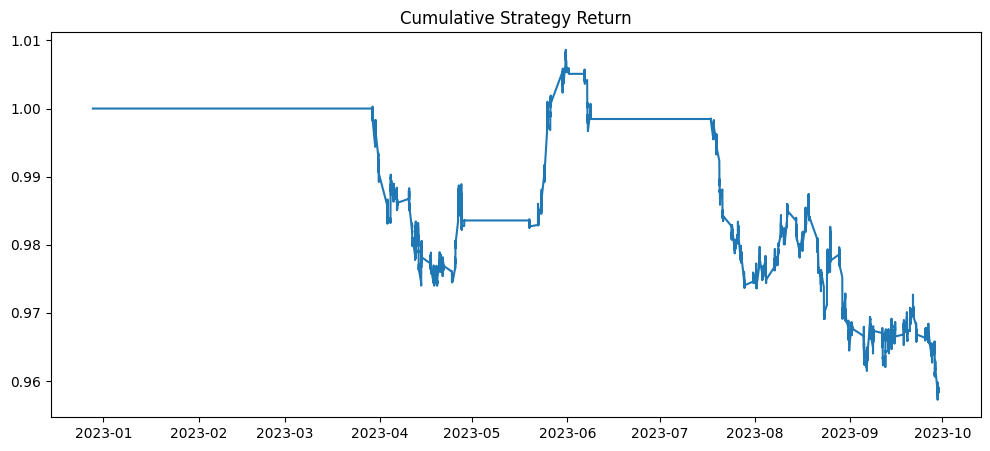

In [66]:
# 7. evalute performance
df["cum_ret"] = (1 + df["strategy_ret"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(df["cum_ret"])
plt.title("Cumulative Strategy Return")
plt.show()

## Adding Transaction Cost

In [70]:
df["turnover"] = df["position"].diff().abs()


In [72]:
# assume 0.0004 per transaction cost
cost_per_trade = 0.0002

df["cost"] = df["turnover"] * cost_per_trade
df["strategy_ret_net"] = df["strategy_ret"] - df["cost"]

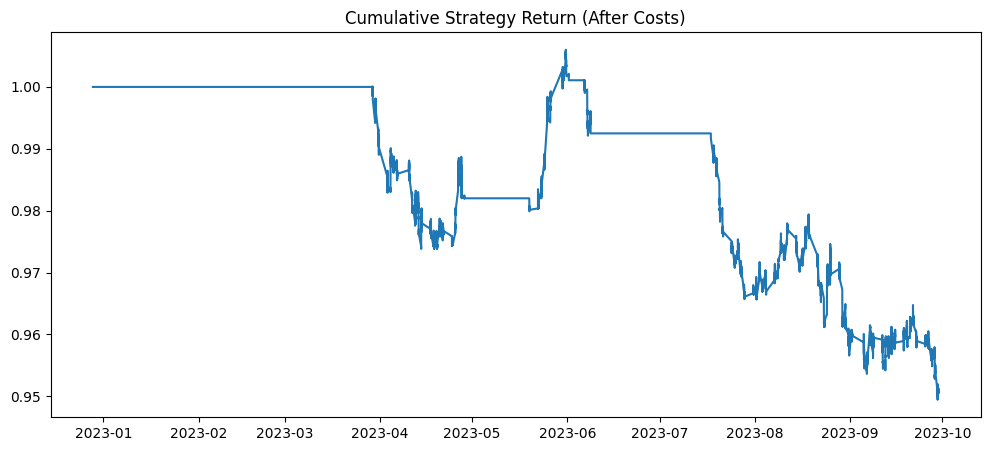

In [74]:
# plot return after including transaction cost
df["cum_ret_net"] = (1 + df["strategy_ret_net"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(df["cum_ret_net"])
plt.title("Cumulative Strategy Return (After Costs)")
plt.show()

## Performance Metrics

In [78]:
import numpy as np
# there are 252 trading days
annual_factor = np.sqrt(252 * 390)

sharpe = annual_factor * df["strategy_ret_net"].mean() / df["strategy_ret_net"].std()

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -1.9125580168240512


In [80]:
cum = df["cum_ret_net"]
rolling_max = cum.cummax()
drawdown = cum / rolling_max - 1
max_dd = drawdown.min()

print("Max Drawdown:", max_dd)

Max Drawdown: -0.0562370173194916


In [82]:
total_return = df["cum_ret_net"].iloc[-1] - 1
print("Total Return:", total_return)

Total Return: -0.04913664081723412


### Based on above statistics, the model performance is poor and seems like it's cause by having too much turnover. 

In [86]:
df["turnover"].sum()

41.0

In [88]:
# annualized turnover
bars_per_year = 252 * 390
annual_turnover = df["turnover"].sum() / len(df) * bars_per_year
print("Annual Turnover:", annual_turnover)

Annual Turnover: 44.57093555737451


In [90]:
# threshold grid search
entry_grid = [1.0, 1.5, 2.0]
exit_grid = [0.25, 0.5, 0.75]

results = []

for entry in entry_grid:
    for exit in exit_grid:

        df["position"] = 0
        df.loc[df["zscore"] < -entry, "position"] = 1
        df.loc[df["zscore"] > entry, "position"] = -1

        df["position"] = df["position"].replace(0, np.nan).ffill()
        df.loc[df["zscore"].abs() < exit, "position"] = 0
        df["position"] = df["position"].ffill().fillna(0)

        strategy_ret = df["position"].shift(1) * df["spread_ret"]

        sharpe = np.sqrt(252*390) * strategy_ret.mean() / strategy_ret.std()

        results.append((entry, exit, sharpe))

results_df = pd.DataFrame(results, columns=["entry","exit","sharpe"])

print(results_df)

KeyError: 'spread_ret'

In [ ]:
# transaction cost sensitivity
costs = [0, 0.0001, 0.0002, 0.0004]

for cost in costs:

    trades = df["position"].diff().abs()

    strategy_ret = (
        df["position"].shift(1) * df["spread_ret"]
        - trades * cost
    )

    sharpe = np.sqrt(252*390) * strategy_ret.mean() / strategy_ret.std()

    print("cost:", cost, "Sharpe:", sharpe)